# Linear Regression using Gradient Descent (From Scratch)


#The objective of this notebook is to understand and implement Linear Regression
#from scratch using Gradient Descent without using scikit-learn's LinearRegression() model.

In this notebook we will:

 Understand the mathematical intuition behind Linear Regression.
 Learn how Gradient Descent optimizes the model parameters.
 Implement every step manually using NumPy.
 Train the model.
 Evaluate model performance.
 Compare the implementation with scikit-learn in the next notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
## Load the Transformed Dataset

#the transformed dataset produced by the Data Transformation stage is used to train the Linear Regression model.

In [3]:
import os

print(os.getcwd())

c:\Users\Greesha Vaishnavi\Desktop\dsprojects\Regression_01\research


In [4]:
import os

print(os.listdir())

['01_data_ingestion.ipynb', '02_data_validation.ipynb', '03_data_transformation.ipynb', '04_linear_gradient_descent.ipynb', 'trials.ipynb']


In [5]:
from pathlib import Path

project_root = Path.cwd().parent

print(project_root)
print((project_root / "artifacts").exists())

c:\Users\Greesha Vaishnavi\Desktop\dsprojects\Regression_01
True


In [6]:
from pathlib import Path
import numpy as np

project_root = Path.cwd().parent

train_path = project_root / "artifacts" / "data_transformation" / "train.npy"
test_path = project_root / "artifacts" / "data_transformation" / "test.npy"

print(train_path)
print(test_path)
print(train_path.exists())
print(test_path.exists())                        # train.npy & test.npy


c:\Users\Greesha Vaishnavi\Desktop\dsprojects\Regression_01\artifacts\data_transformation\train.npy
c:\Users\Greesha Vaishnavi\Desktop\dsprojects\Regression_01\artifacts\data_transformation\test.npy
True
True


In [7]:
train_arr = np.load(train_path)               # Load train.npy
test_arr = np.load(test_path)

In [8]:
X_train = train_arr[:, :-1]              # Separate X and y all rows and colums expect last one target variable
y_train = train_arr[:, -1]               # all rows and only target variable

X_test = test_arr[:, :-1]
y_test = test_arr[:, -1]

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)                # Feature Scaling
X_test = scaler.transform(X_test)

In [10]:
print(X_train.shape)
print(y_train.shape)                      

print(X_test.shape)
print(y_test.shape)

(436, 14)
(436,)
(109, 14)
(109,)


In [11]:
# Number of input features
n_features = X_train.shape[1]             # step 1 Initialize weight and bias

# Initialize weights
w = np.zeros(n_features)
                                         #Right now, the model doesn't know anything about the data
# Initialize bias
b = 0.0                                   #weight = 0 , bias = 0

print("Weights:")
print(w)

print("\nBias:")
print(b)

Weights:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Bias:
0.0


In [12]:
def predict(X, w, b):
    """                                                                
    Predict target values using current weights and bias.
    """

    y_pred = np.dot(X, w) + b                         #Step 2: Prediction Function

    return y_pred                                     # for prediction ^y​=Xw+b 

In [13]:
y_pred = predict(X_train, w, b)

print(y_pred[:10])                

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


# Cost Function

#The Cost Function measures how far the predicted values are from the actual values.

#If the cost is:

# High → Poor model
# Low → Better model

# For Linear Regression, we use Mean Squared Error (MSE)/cost function.

# The objective of Gradient Descent is to minimize this cost.
# here the prediction area is 0 bad prediction large cost bad model so we need to minimize the cost by gradient descent


In [14]:
def compute_cost(y_true, y_pred):
    """
    Compute Mean Squared Error Cost
    """                                             #MSE or cost function formula

    m = len(y_true)                                 # J(w,b)=1/2m ​i=1∑m ​(y^​i​−yi​)2

    cost = (1 / (2 * m)) * np.sum((y_pred - y_true) ** 2)   #m = Number of training examples, ^y= Predicted value ,y = Actual value

    return cost

In [15]:
cost = compute_cost(y_train, y_pred)

print("Initial Cost:", cost)

Initial Cost: 12617396203243.809


# Gradient Calculation

#The gradient measures how the cost changes with respect to the model parameters.

# It tells us:
# How to update the weights.
# How to update the bias.

# The objective is to move in the direction that reduces the cost.

In [16]:
def compute_gradient(X, y_true, y_pred):
    """
    Compute gradients for weights and bias.
    """

    m = len(y_true)          # step 4 : Compute Gradient here it dont kw how to reduce cost so it uses this method to reduce cost

    # Gradient of weights
    dw = (1 / m) * np.dot(X.T, (y_pred - y_true))         # dw=1/m ​XT(y^​−y)

    # Gradient of bias
    db = (1 / m) * np.sum(y_pred - y_true)               # db=1/m​∑(y^​−y)

    return dw, db

In [17]:
dw, db = compute_gradient(X_train, y_train, y_pred)

print("Weight Gradient Shape:", dw.shape)
print("Bias Gradient:", db)                 # db is a single number because there is only one bias.

print("\nFirst 5 Weight Gradients:")
print(dw[:5])

Weight Gradient Shape: (14,)
Bias Gradient: -4706527.385321101

First 5 Weight Gradients:
[-533376.98108148 -464216.96830487 -362888.01936858 -132176.72957895
 -826309.00124322]


# Gradient Descent Algorithm

Gradient Descent is an optimization algorithm used to minimize the cost function.

During each iteration, the algorithm:

1. Predicts the output.
2. Calculates the cost.
3. Computes the gradients.
4. Updates the weights and bias.
5. Repeats until the cost converges.

The objective is to learn the optimal model parameters that minimize prediction error.

In [18]:
def gradient_descent(
    X,
    y,
    w,                   # step 5 : Gradient descent The process of moving down the slope until reaching the lowest point.
    b,                    # till it find the best prediction value better than actual value 
    learning_rate,
    iterations
):

    cost_history = []

    for i in range(iterations):

        # Step 1: Prediction
        y_pred = predict(X, w, b)

        # Step 2: Cost
        cost = compute_cost(y, y_pred)

        # Step 3: Gradient
        dw, db = compute_gradient(X, y, y_pred)

        # Step 4: Update Weights
        w = w - learning_rate * dw

        # Step 5: Update Bias
        b = b - learning_rate * db

        # Store Cost
        cost_history.append(cost)

    return w, b, cost_history

In [19]:
learning_rate = 0.01
iterations = 1000                               # Step 6: Train the Model

w, b, cost_history = gradient_descent(
    X_train,
    y_train,
    w,
    b,
    learning_rate,
    iterations
)

In [20]:
print("Final Bias:")
print(b)                             # Check the Learned Parameters i.e., weight and bias

print("\nFirst Five Weights:")
print(w[:5])

Final Bias:
4706324.198662907

First Five Weights:
[129349.20502453  90076.35499613 185032.25141699 150069.55945635
 365962.14471915]


In [21]:
print("Initial Cost :", cost_history[0])
print("Final Cost   :", cost_history[-1])         #Step 7: Check if Learning Happened

Initial Cost : 12617396203243.809
Final Cost   : 484182913889.13336


# Prediction on Test Data

After training, the learned weights and bias are used to predict house prices
for the unseen test dataset.

This helps evaluate how well the model generalizes to new data.

In [22]:
# Predict House Prices

y_test_pred = predict(X_test, w, b)   # Step 8: Predict on Test Data

print(y_test_pred[:10])

[5159758.30385423 7222898.51978644 3110668.26506504 4613865.53406675
 3298505.36893674 3533966.48650971 5614921.07918174 6370122.29425501
 2724918.02308632 2631545.75535157]


# Model Evaluation

The performance of the model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [23]:
mae = mean_absolute_error(y_test, y_test_pred)

mse = mean_squared_error(y_test, y_test_pred)
                                                 # Step 9: Model Evaluation : actual price to predicted price
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_test_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 969533.60
MSE  : 1754017594344.16
RMSE : 1324393.29
R2   : 0.6530


# Cost vs Iterations

The graph below shows how the cost decreases as Gradient Descent updates
the model parameters.

A decreasing cost indicates successful convergence.

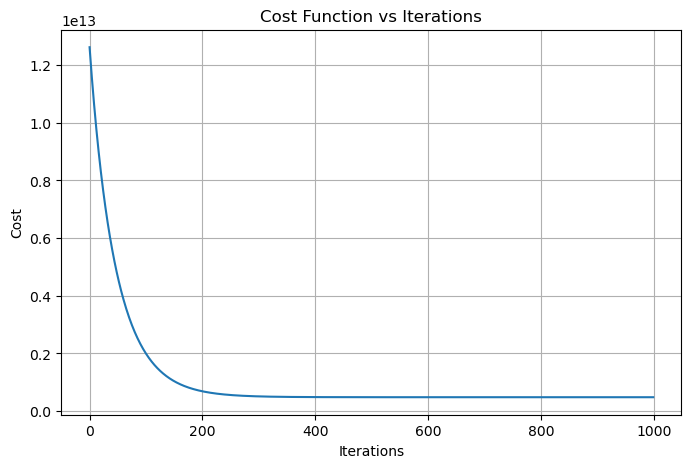

In [24]:
plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.title("Cost Function vs Iterations")      #Step 10: Cost Reduction Graph

plt.xlabel("Iterations")

plt.ylabel("Cost")

plt.grid(True)

plt.show()

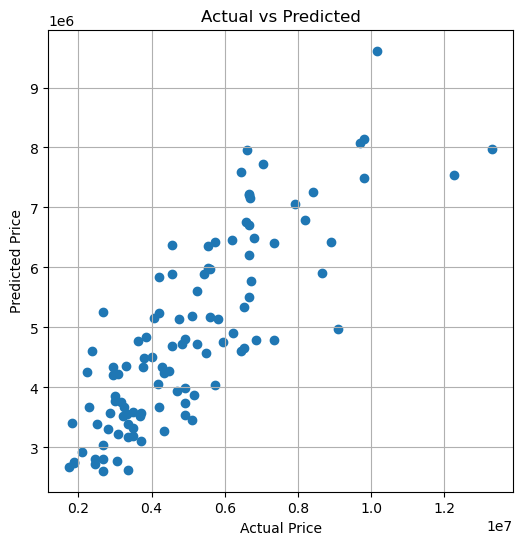

In [25]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_test_pred)   # Step 11: Actual vs Predicted

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

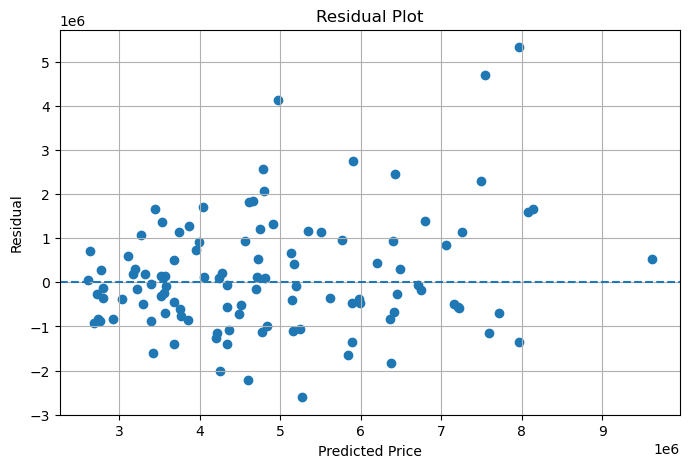

In [26]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8,5))

plt.scatter(y_test_pred, residuals)   # Step 12: Residual Plot

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [27]:
print(X_train.shape)
print(y_train.shape)
print(cost_history[-1])


(436, 14)
(436,)
484182913889.13336
